In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from astropy import units as u
import numpy as np
from disktab import AGNDisk
import seaborn as sns
from matplotlib import pyplot as plt
import pandas as pd
from astropy.constants import G, c, sigma_sb, k_B, m_p

In [2]:
disk = AGNDisk()

# Set required parameters
disk.M = 1e8 * u.Msun          # Central black hole mass
disk.Mdot = (1e21 * u.kg / u.s)  # Mass accretion rate
disk.alpha = 0.1               # Shakura-Sunyaev viscosity parameter

mbh = 1*u.Msun
# Generate the disk profile
# rvals can be passed as dimensionless (assumed multiples of Rg) or with units
# If omitted, uses default: 200 log-spaced points from 10 to 10^7 Rg
#df = disk.spacehub_pretab(rvals=np.linspace(10, 10**7, 500))
df = disk.spacehub_pretab(rvals=np.logspace(1, 7, 2000))
disk.model

/home/mars/Computing/AGN/SpaceHub-Tinkering/disktab/disktab.py:1117: UserWarning: Zone boundary smoothing applied (CubicHermiteSpline, n_gap=100, w=100): 200 rows [911, 1111) around index 1011 (R/Rg ≈ 10827.2) replaced for grad_P and grad_Sigma. Originals preserved in grad_P_raw / grad_Sigma_raw.
  self.generate(rvals=rvals)


,R,R/Rg,Tc,rho,P,cs,H,visc,Sigma,Q,zone,grad_T,grad_Sigma,grad_P,grad_P_raw,grad_Sigma_raw
0,1.476625e+12,1.000000e+01,344436.084407,5.701130e-05,3.819626e+06,258839.150165,4.031619e+09,1.043541e+14,229838.190410,344828.100643,Standard,0.350353,0.100155,1.450723,1.450723,0.100155
1,1.486866e+12,1.006935e+01,343603.087900,5.632599e-05,3.781521e+06,259106.813731,4.077844e+09,1.056597e+14,229679.153139,341861.255203,Standard,0.351211,0.090856,1.452438,1.452438,0.090856
2,1.497177e+12,1.013918e+01,342768.042819,5.566456e-05,3.743707e+06,259335.253508,4.123971e+09,1.069491e+14,229549.728556,338824.768685,Standard,0.352896,0.072471,1.455807,1.455807,0.072471
3,1.507560e+12,1.020950e+01,341931.117489,5.502597e-05,3.706187e+06,259525.345799,4.170000e+09,1.082221e+14,229449.193023,335723.211439,Standard,0.354521,0.054505,1.459058,1.459058,0.054505
4,1.518016e+12,1.028031e+01,341092.470473,5.440928e-05,3.668961e+06,259677.953509,4.215932e+09,1.094785e+14,229376.853534,332561.034723,Standard,0.356092,0.036946,1.462199,1.462199,0.036946
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1.436363e+18,9.727338e+06,35.191179,1.067907e-17,3.918884e-10,6057.794149,9.052219e+16,5.483648e+19,1.933385,1.000000,Self-Reg,0.747436,1.499869,2.999738,2.999738,1.499869
1996,1.446324e+18,9.794798e+06,35.009860,1.045993e-17,3.838475e-10,6057.799620,9.146558e+16,5.540801e+19,1.913447,1.000000,Self-Reg,0.747449,1.499870,2.999739,2.999739,1.499870
1997,1.456355e+18,9.862727e+06,34.829472,1.024529e-17,3.759715e-10,6057.805071,9.241880e+16,5.598551e+19,1.893715,1.000000,Self-Reg,0.747462,1.499870,2.999740,2.999740,1.499870
1998,1.466455e+18,9.931126e+06,34.650010,1.003506e-17,3.682572e-10,6057.810504,9.338195e+16,5.656902e+19,1.874187,1.000000,Self-Reg,0.747475,1.499870,2.999741,2.999741,1.499870


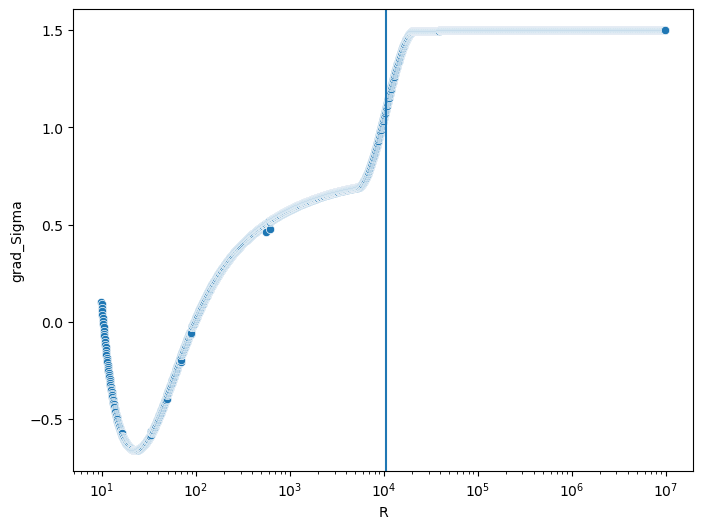

In [3]:
fig, ax = plt.subplots(figsize=(8,6))
ax.axvline(disk.selfreg_threshold.to(u.AU).value)
sns.scatterplot(data=df, x="R", y="grad_Sigma")
ax.set_xscale("log")


In [4]:
Rg = df['R/Rg'].values
R = df['R'].values * u.m
H = df['H'].values * u.m
rho = df['rho'].values * u.kg / u.m**3
Tc = df['Tc'].values * u.K
Sigma = df['Sigma'].values * u.kg / u.m**2
#Calculate Rosseland mean opacity
K0 = 0.4 * u.cm**2 / u.g                          # electron scattering
K1 = 6.4e22 * u.cm**5 / u.g**2 * u.K**(7/2)       # Kramers 

kappa = K0 + (K1 * rho * Tc**(-3.5))

#Calculate thermal diffusivity - assume adiabatic index 4/3 in radiation pressure zone and 5/3 in gas pressure zone 
P_rad = 4 * sigma_sb * Tc**4 / (3 * c)
P_gas = rho * k_B * Tc / (disk.mu * m_p)
#If P_rad > P_gas, 4/3
gamma = np.where(P_rad > P_gas, 4/3, 5/3)
Omega = np.sqrt(G * disk.M / R**3)
chi = 16 * gamma * (gamma - 1) * sigma_sb * Tc**4 / (3 * kappa * rho**2 * H**2 * Omega**2)

#Calculate f_gamma (thermal saturation factor, Gilbaum+2025 Eq. A5)
x = (chi / (H**2 * Omega)).decompose().value

sqrt_halfx = np.sqrt(x/2)
f_gamma = (sqrt_halfx + 1/gamma) / (sqrt_halfx + 1)

#Calculate torque coefficients (Gilbaum+2025 Eq. A3-A4, JM17)
grad_T = df['grad_T'].values
grad_Sigma = df['grad_Sigma'].values

#Lindblad torque coefficient (Eq. A4)
C_L = (-2.34 + 0.1 * grad_Sigma - 1.5 * grad_T) * f_gamma
#Corotation torque coefficient (Eq. A3)
C_CR = (0.46 - 0.96 * grad_Sigma + 1.8 * grad_T) / gamma
#Total adiabatic coefficient
jm_lin_tot = C_L + C_CR
#Linear isothermal C_I = -1.36 - 0.54\Nabla_\Sigma - 0.5\Nabla_T
jm_lin_iso = -1.36 - (0.54 * grad_Sigma) - (0.5 * grad_T)

#Calc Gamma0
q = mbh/disk.M
Gamma0 = q**2 * Sigma * R**4 * Omega**2 * (H/R)**(-3)

#Calc net torque
GammaI_iso = jm_lin_iso * (H / R) * Gamma0
GammaI_tot = jm_lin_tot * (H / R) * Gamma0

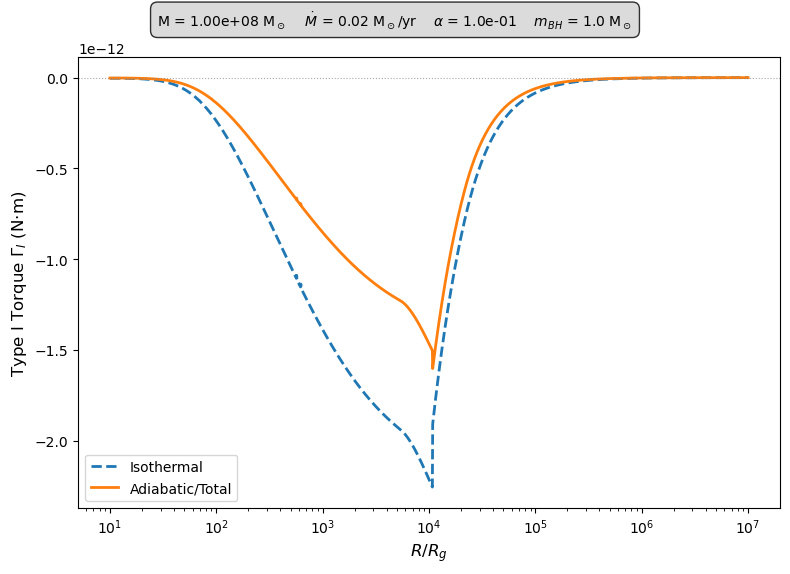

In [5]:
from matplotlib.ticker import LogLocator, FuncFormatter

fig, ax = plt.subplots(figsize=(8, 6))
sns.lineplot(x=Rg, y=GammaI_iso.value, ax=ax, label="Isothermal", linestyle="--", linewidth=2)
sns.lineplot(x=Rg, y=GammaI_tot.value, ax=ax, label="Adiabatic/Total", linewidth=2)

ax.set_xscale("log")

ax.set_xlabel(r"$R / R_g$", fontsize=12)
ax.set_ylabel(r"Type I Torque $\Gamma_I$ (N$\cdot$m)", fontsize=12)

ax.xaxis.set_major_locator(LogLocator(base=10, numticks=10))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=100))

ax.ticklabel_format(axis='y', style='scientific', scilimits=(0, 0))

ax.legend(loc='best', fontsize=10)

ax.axhline(0, color='gray', linestyle=':', linewidth=0.8, alpha=0.7)

M_str = f"{disk.M.to(u.Msun).value:.2e} M$_\\odot$"
Mdot_str = f"{disk.Mdot.to(u.Msun/u.yr).value:.2f} M$_\\odot$/yr"
alpha_str = f"{disk.alpha:.1e}"
mbh_str = f"{mbh.to(u.Msun).value:.1f} M$_\\odot$"

param_text = (
    f"M = {M_str}    "
    f"$\\dot{{M}}$ = {Mdot_str}    "
    f"$\\alpha$ = {alpha_str}    "
    f"$m_{{BH}}$ = {mbh_str}"
)

bbox_props = dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.8, edgecolor='black')
fig.text(
    0.5, 0.95, param_text,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='center',
    bbox=bbox_props
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()